In [21]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


In [22]:
#Các thông số vật lý của hệ con lắc đơn
L1 = 1.0 #Chiều dài của dây treo con lắc 1 (đơn vị: mét)
L2 = 1.0 #Chiều dài của dây treo con lắc 2 (đơn vị: mét)
m1 = 1.0 #Khối lượng của con lắc 1 (đơn vị: kg)
m2 = 1.0 #Khối lượng của con lắc 2 (đơn vị: kg)
g = 9.81 #Gia tốc trọng trường (đơn vị: m/s^2)
end_time = 15 #Khoảng thời gian xét sự chuyển động của hệ con lắc kép
t = np.linspace(0, end_time, 50000) #Tạo mảng thời gian

In [23]:
def double_pendulum_ode_function(state, t, L1, L2, m1, m2, g):
    theta1, omega1, theta2, omega2 = state

    delta_theta = theta1 - theta2
    sin_delta_theta = np.sin(delta_theta)
    cos_delta_theta = np.cos(delta_theta)

    eps = 1e-6 #chống chia cho 0

    den1 = L1 * (2*m1 + m2 - m2*np.cos(2*delta_theta)) + eps
    den2 = L2 * (2*m1 + m2 - m2*np.cos(2*delta_theta)) + eps

    #Gia tốc góc của con lắc 1
    ddot_theta1 = (
        -g * (2 * m1 + m2) * np.sin(theta1)
        - m2 * g * np.sin(theta1 - 2 * theta2)
        - 2 * m2 * sin_delta_theta * (L2 * omega2**2 + L1 * omega1**2 * cos_delta_theta)
    ) / den1

    #Gia tốc góc của con lắc 2
    ddot_theta2 = (
        2 * sin_delta_theta
        * (L1 * omega1**2 * (m1 + m2) + g * (m1 + m2) * np.cos(theta1) + L2 * m2 * omega2**2 * cos_delta_theta)
    ) / den2

    #Gía trị trả về
    return [omega1, ddot_theta1, omega2, ddot_theta2]

In [24]:
import numpy as np
from scipy.integrate import odeint

initial_state_dp = [np.pi/4, 0, np.pi/4 + 0.5, 0] #Điều kiện ban đầu của[theta1, omega1, theta2, omega2]

# Giair số hệ ODE
dp_solution = odeint(double_pendulum_ode_function, initial_state_dp, t, args=(L1, L2, m1, m2, g))

# Trích xuất theta1 và theta2
theta1_numerical = dp_solution[:, 0]
theta2_numerical = dp_solution[:, 2]

print(f"Shape of numerical solution: {dp_solution.shape}")
print(f"First few theta1 values: {theta1_numerical[:5]}")
print(f"First few theta2 values: {theta2_numerical[:5]}")

Shape of numerical solution: (50000, 4)
First few theta1 values: [0.78539816 0.78539796 0.78539734 0.78539632 0.78539488]
First few theta2 values: [1.28539816 1.28539792 1.28539719 1.28539597 1.28539427]


In [25]:
# FCN class definition
class FCN(nn.Module):
    "Defines a connected network"

    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = nn.Tanh
        self.fcs = nn.Sequential(*[
                        nn.Linear(N_INPUT, N_HIDDEN),
                        activation()])
        self.fch = nn.Sequential(*[
                        nn.Sequential(*[
                            nn.Linear(N_HIDDEN, N_HIDDEN),
                            activation()]) for _ in range(N_LAYERS-1)])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)

    def forward(self, x):
        x = torch.cat(
            [x, torch.sin(x), torch.cos(x), torch.sin(2*x), torch.cos(2*x)],
            dim=1
        )
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

In [26]:
# double_pendulum_physics_residuals function
def double_pendulum_physics_residuals(
    theta1, omega1, theta2, omega2, ddot_theta1, ddot_theta2, L1, L2, m1, m2, g
):
    delta_theta = theta1 - theta2
    sin_delta_theta = torch.sin(delta_theta)
    cos_delta_theta = torch.cos(delta_theta)

    eps = 1e-6
    den_term = L1 * (2 * m1 + m2 - m2 * torch.cos(2 * delta_theta)) + eps
    den_term = torch.where(torch.abs(den_term) < 1e-6, torch.full_like(den_term, 1e-6), den_term)

    # Expected ddot_theta1 from ODEs
    expected_ddot_theta1 = (
        -g * (2 * m1 + m2) * torch.sin(theta1)
        - m2 * g * torch.sin(theta1 - 2 * theta2)
        - 2 * m2 * sin_delta_theta * (L2 * omega2**2 + L1 * omega1**2 * cos_delta_theta)
    ) / den_term

    den_term2 = L2 * (2 * m1 + m2 - m2 * torch.cos(2 * delta_theta)) + eps
    den_term2 = torch.where(torch.abs(den_term2) < 1e-6, torch.full_like(den_term2, 1e-6), den_term2)

    # Expected ddot_theta2 from ODEs
    expected_ddot_theta2 = (
        2 * sin_delta_theta
        * (L1 * omega1**2 * (m1 + m2) + g * (m1 + m2) * torch.cos(theta1) + L2 * m2 * omega2**2 * cos_delta_theta)
    ) / den_term2

    # Calculate residuals
    residual1 = ddot_theta1 - expected_ddot_theta1
    residual2 = ddot_theta2 - expected_ddot_theta2

    return residual1, residual2

In [27]:
def plot_result_double_pendulum(x, theta1_numerical, theta2_numerical, yh_theta1, yh_theta2, x_data, y_data=None, xp=None, i=0):
    "Pretty plot training results for a double pendulum"
    plt.figure(figsize=(12, 6))

    # Subplot for theta1
    plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
    # Sample points for a sparser plot
    sampling_step = 400  # Adjust this value to control sparsity
    x_sampled = x.cpu().numpy()[::sampling_step]
    theta1_numerical_sampled = theta1_numerical[::sampling_step]
    plt.plot(x_sampled, theta1_numerical_sampled, 'o', markersize=5, color="tab:red", alpha=0.9, label="Numercial PDE solution") # Corrected to use sampled data
    plt.plot(x.cpu().numpy(), yh_theta1.cpu().numpy(), color="tab:blue", linewidth=2.5, alpha=1, label="NN prediction")
    if y_data is not None: # Training data for theta1
        plt.scatter(x_data.cpu().numpy(), y_data[:, 0].cpu().numpy(), s=70, marker='s', color="green", alpha=1, label='Training data')
    plt.xlabel('t', fontsize=12)
    plt.ylabel(r'$  Theta_1(t)$', fontsize=12)
    plt.tick_params(labelsize=10)
    plt.legend(frameon=False, fontsize="small")
    plt.ylim(-np.pi * 1.1, np.pi * 1.1) # Adjust y-axis limits for angles
    plt.grid(True)
    # Add vertical line for end_time (assuming end_time is accessible globally or passed)
    plt.axvline(x=5.5, color='black', linestyle='--', linewidth=1.5)


    # Subplot for theta2
    plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
    # Sample points for a sparser plot
    sampling_step = 400  # Adjust this value to control sparsity
    x_sampled = x.cpu().numpy()[::sampling_step]
    theta2_numerical_sampled = theta2_numerical[::sampling_step]
    plt.plot(x_sampled, theta2_numerical_sampled, 'o', markersize=5, color="tab:red", alpha=0.9, label="Numerical PDE solution") # Corrected to use sampled data
    plt.plot(x.cpu().numpy(), yh_theta2.cpu().numpy(), color="tab:blue", linewidth=2.5, alpha=1, label="NN prediction")
    if y_data is not None: # Training data for theta2
        plt.scatter(x_data.cpu().numpy(), y_data[:, 1].cpu().numpy(), s=70, marker='s', color="green", alpha=1, label='Training data')
    plt.xlabel('t', fontsize=12)
    plt.ylabel(r'$  Theta_2(t)$', fontsize=12)
    plt.tick_params(labelsize=10)
    plt.legend(frameon=False, fontsize="small")
    plt.ylim(-np.pi * 1.1, np.pi * 1.1) # Adjust y-axis limits for angles
    plt.grid(True)
    # Add vertical line for end_time (assuming end_time is accessible globally or passed)
    plt.axvline(x=5.5, color='black', linestyle='--', linewidth=1.5)



    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    # plt.show()

def save_gif_PIL(outfile, files, fps=5, loop=0):
    "Helper function for saving GIFs"
    imgs = [Image.open(file) for file in files]
    imgs[0].save(fp=outfile, format='GIF', append_images=imgs[1:], save_all=True, duration=int(1000/fps), loop=loop)

In [28]:
initial_state_dp = [np.pi/4, 0, np.pi/4+0.5, 0] #Điều kiện ban đầu[theta1, omega1, theta2, omega2]

dp_solution = odeint(double_pendulum_ode_function, initial_state_dp, t, args=(L1, L2, m1, m2, g))

# Extract theta1 and theta2
theta1_numerical = dp_solution[:, 0]
theta2_numerical = dp_solution[:, 2]

print(f"Shape of numerical solution: {dp_solution.shape}")
print(f"First few theta1 values: {theta1_numerical[:5]}")
print(f"First few theta2 values: {theta2_numerical[:5]}")

# 1. Convert numerical solutions to a single PyTorch tensor y_numerical
y_numerical = torch.tensor(np.stack([theta1_numerical, theta2_numerical], axis=1), dtype=torch.float32)

# 2. Create training data (x_data_dp, y_data_dp)
t_torch = torch.tensor(t, dtype=torch.float32).view(-1, 1)
x_data_dp = t_torch[:20000:2000]
y_data_dp = y_numerical[:20000:2000]
print(f"Shape of x_data_dp: {x_data_dp.shape}")
print(f"Shape of y_data_dp: {y_data_dp.shape}")

Shape of numerical solution: (50000, 4)
First few theta1 values: [0.78539816 0.78539796 0.78539734 0.78539632 0.78539488]
First few theta2 values: [1.28539816 1.28539792 1.28539719 1.28539597 1.28539427]
Shape of x_data_dp: torch.Size([10, 1])
Shape of y_data_dp: torch.Size([10, 2])


Iteration 1000, Loss_data: 0.213259, Loss_physics: 0.268299, Losss_ic: 0.001491, Loss_energy: 0.381798, Total Loss: 3.083495
Iteration 2000, Loss_data: 0.112193, Loss_physics: 0.152214, Losss_ic: 0.000316, Loss_energy: 0.333261, Total Loss: 1.699298
Iteration 3000, Loss_data: 0.057727, Loss_physics: 0.157412, Losss_ic: 0.000112, Loss_energy: 0.293676, Total Loss: 1.672371
Iteration 4000, Loss_data: 0.028997, Loss_physics: 0.071334, Losss_ic: 0.000050, Loss_energy: 0.198506, Total Loss: 0.767203
Iteration 5000, Loss_data: 0.024176, Loss_physics: 0.051186, Losss_ic: 0.000043, Loss_energy: 0.155203, Total Loss: 0.555888


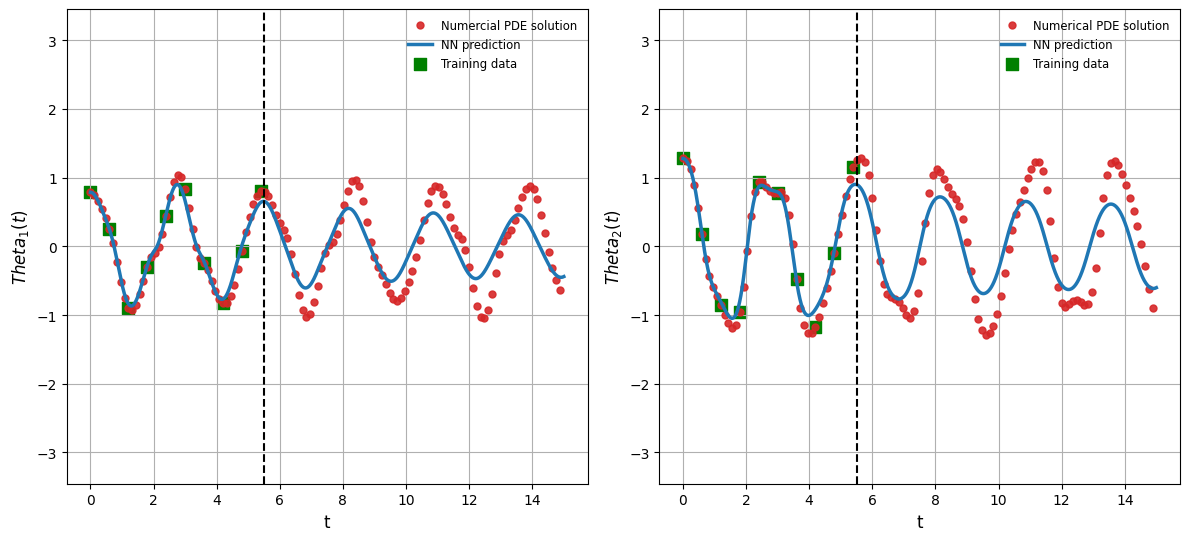

Iteration 6000, Loss_data: 0.017602, Loss_physics: 0.051462, Losss_ic: 0.000216, Loss_energy: 0.107416, Total Loss: 0.564548
Iteration 7000, Loss_data: 0.012789, Loss_physics: 0.035742, Losss_ic: 0.000031, Loss_energy: 0.076949, Total Loss: 0.381054
Iteration 8000, Loss_data: 0.011046, Loss_physics: 0.050277, Losss_ic: 0.000116, Loss_energy: 0.058982, Total Loss: 0.531342
Iteration 9000, Loss_data: 0.009096, Loss_physics: 0.023423, Losss_ic: 0.000354, Loss_energy: 0.048602, Total Loss: 0.283561
Iteration 10000, Loss_data: 0.005848, Loss_physics: 0.012944, Losss_ic: 0.000008, Loss_energy: 0.024692, Total Loss: 0.138517


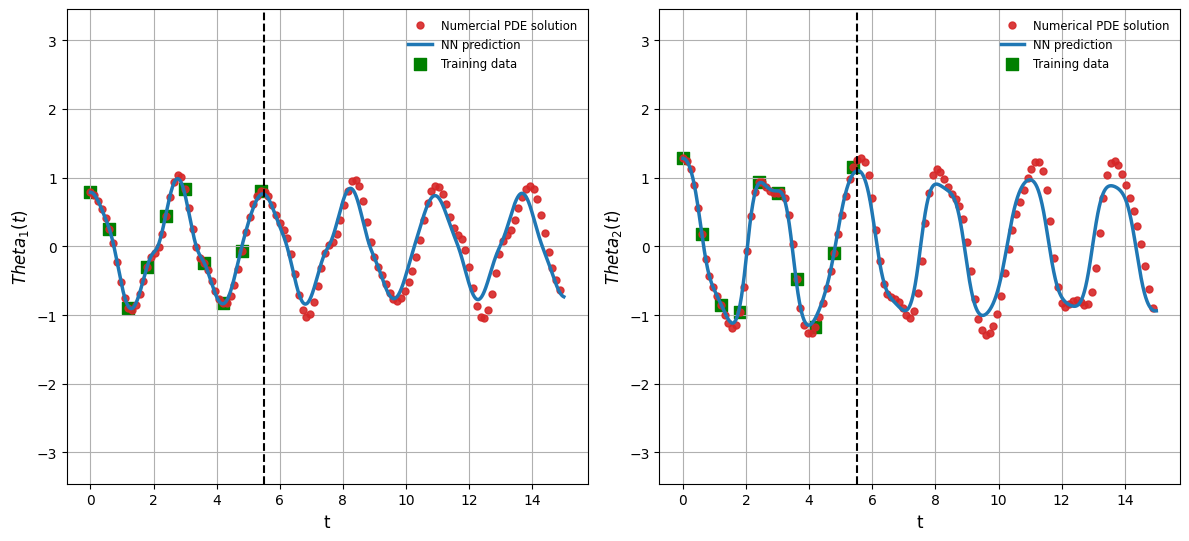

Iteration 11000, Loss_data: 0.004765, Loss_physics: 0.011996, Losss_ic: 0.000006, Loss_energy: 0.018901, Total Loss: 0.127230
Iteration 12000, Loss_data: 0.004087, Loss_physics: 0.066299, Losss_ic: 0.000161, Loss_energy: 0.013064, Total Loss: 0.684447
Iteration 13000, Loss_data: 0.002661, Loss_physics: 0.010178, Losss_ic: 0.000004, Loss_energy: 0.009564, Total Loss: 0.105753
Iteration 14000, Loss_data: 0.002237, Loss_physics: 0.006704, Losss_ic: 0.000009, Loss_energy: 0.007752, Total Loss: 0.070913
Iteration 15000, Loss_data: 0.001998, Loss_physics: 0.008617, Losss_ic: 0.000191, Loss_energy: 0.009290, Total Loss: 0.108191


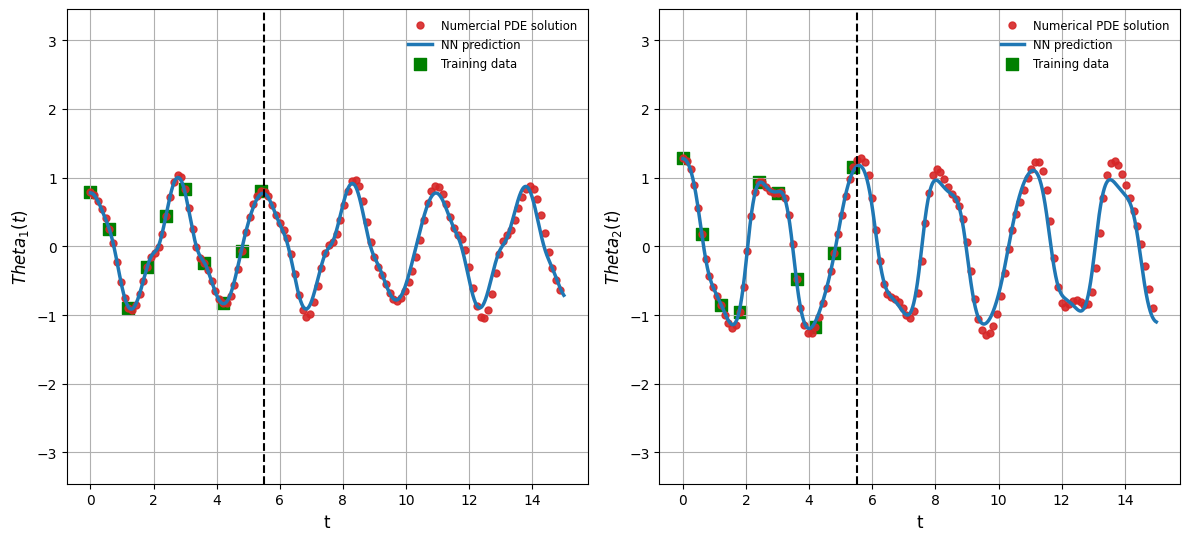

Iteration 16000, Loss_data: 0.001608, Loss_physics: 0.006750, Losss_ic: 0.000097, Loss_energy: 0.006835, Total Loss: 0.079477
Iteration 17000, Loss_data: 0.001175, Loss_physics: 0.002430, Losss_ic: 0.000002, Loss_energy: 0.003593, Total Loss: 0.026010
Iteration 18000, Loss_data: 0.001111, Loss_physics: 0.004544, Losss_ic: 0.000041, Loss_energy: 0.002698, Total Loss: 0.050898
Iteration 19000, Loss_data: 0.000859, Loss_physics: 0.006212, Losss_ic: 0.000031, Loss_energy: 0.003399, Total Loss: 0.066421
Iteration 20000, Loss_data: 0.000755, Loss_physics: 0.003061, Losss_ic: 0.000008, Loss_energy: 0.002069, Total Loss: 0.032391


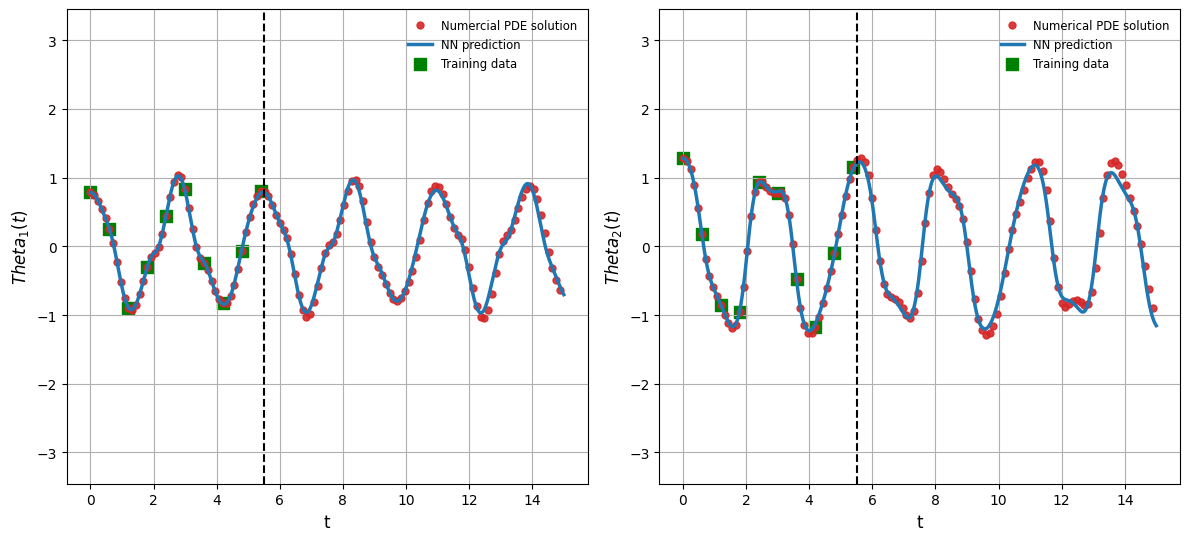

Iteration 21000, Loss_data: 0.000595, Loss_physics: 0.002581, Losss_ic: 0.000004, Loss_energy: 0.001499, Total Loss: 0.026924
Iteration 22000, Loss_data: 0.000512, Loss_physics: 0.002460, Losss_ic: 0.000098, Loss_energy: 0.001710, Total Loss: 0.035080
Iteration 23000, Loss_data: 0.000431, Loss_physics: 0.000948, Losss_ic: 0.000002, Loss_energy: 0.000873, Total Loss: 0.010218
Iteration 24000, Loss_data: 0.000383, Loss_physics: 0.001304, Losss_ic: 0.000004, Loss_energy: 0.000903, Total Loss: 0.013882
Iteration 25000, Loss_data: 0.000457, Loss_physics: 0.002762, Losss_ic: 0.000051, Loss_energy: 0.000749, Total Loss: 0.033284


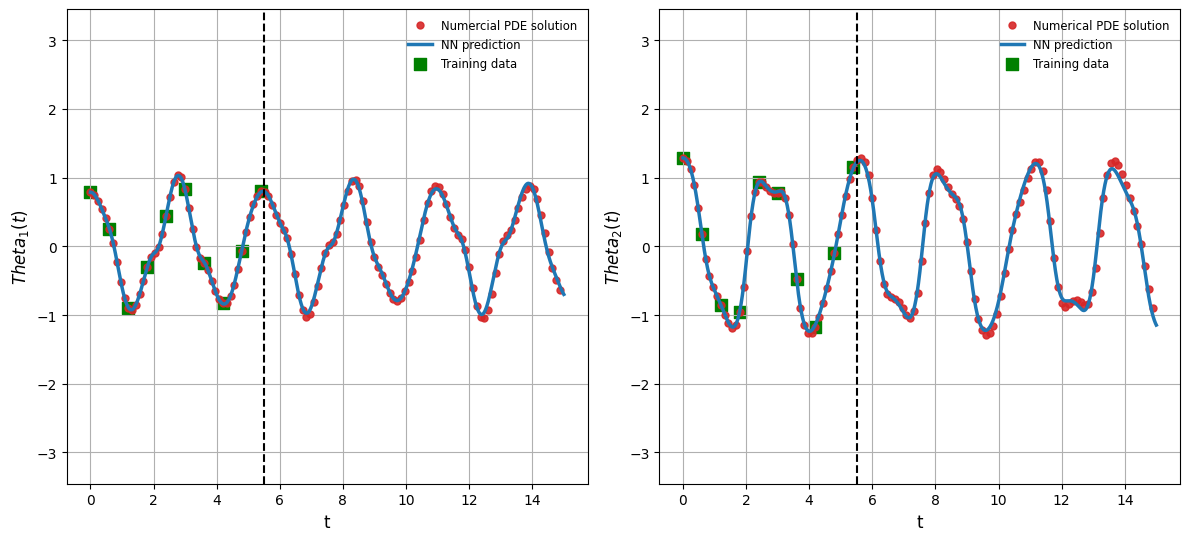

Iteration 26000, Loss_data: 0.000278, Loss_physics: 0.002125, Losss_ic: 0.000004, Loss_energy: 0.000493, Total Loss: 0.021971
Iteration 27000, Loss_data: 0.000317, Loss_physics: 0.012826, Losss_ic: 0.000020, Loss_energy: 0.000664, Total Loss: 0.130678
Iteration 28000, Loss_data: 0.000210, Loss_physics: 0.001105, Losss_ic: 0.000001, Loss_energy: 0.000414, Total Loss: 0.011373
Iteration 29000, Loss_data: 0.000241, Loss_physics: 0.002429, Losss_ic: 0.000042, Loss_energy: 0.000510, Total Loss: 0.028778
Iteration 30000, Loss_data: 0.000148, Loss_physics: 0.000300, Losss_ic: 0.000000, Loss_energy: 0.000246, Total Loss: 0.003201


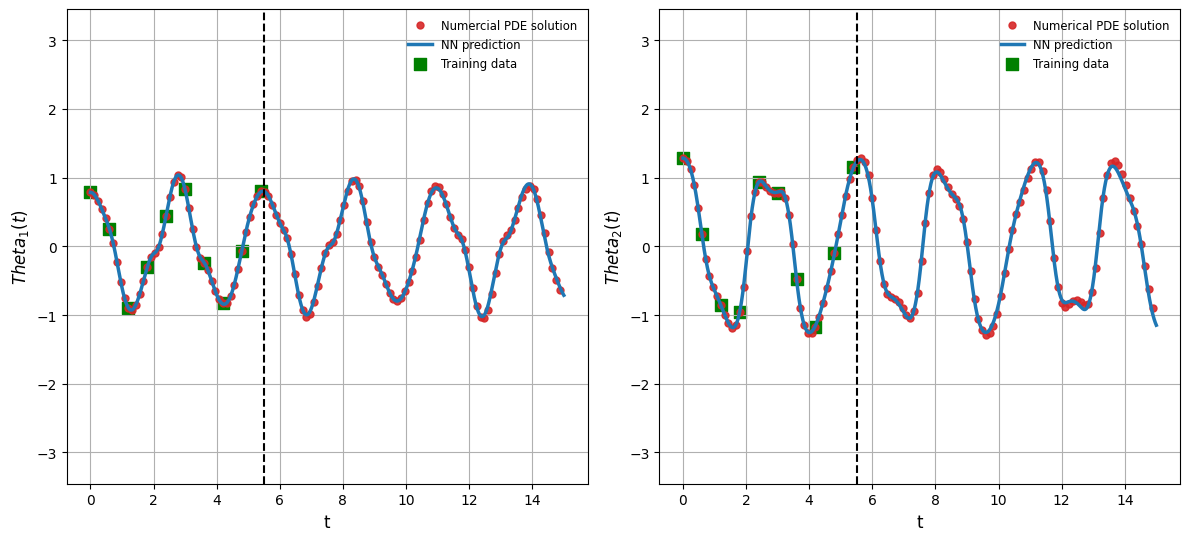

Training complete. GIF saved to pinn_double_pendulum.gif


In [29]:
import numpy as np
from scipy.integrate import odeint

#Hàm năng lượng
def double_pendulum_energy(theta1, dtheta1, theta2, dtheta2, L1, L2, m1, m2, g):
    kinetic = (
        0.5 * (m1 + m2) * L1**2 * dtheta1**2
        + 0.5 * m2 * L2**2 * dtheta2**2
        + m2 * L1 * L2 * dtheta1 * dtheta2 * torch.cos(theta1 - theta2)
    )

    potential = (
        -(m1 + m2) * g * L1 * torch.cos(theta1)
        - m2 * g * L2 * torch.cos(theta2)
    )

    return kinetic + potential

x_physics = torch.linspace(0, end_time, 1000).view(-1,1).requires_grad_(True)
lambda1 = 1 #trọng số loss data
lambda2 = 10 #trọng số loss physics
lambda3 = 100 #trọng số loss ic (điều kiện ban đầu)
lambda4 = 0.1 #trọng số loss energy

dp_model = FCN(5, 2, 128, 6)
optimizer_dp = torch.optim.Adam(dp_model.parameters(), lr=5e-4)
files_dp = []

# Lists to store loss values for plotting
loss_data_history = []
loss_physics_history = []
loss_ic_history = []
loss_energy_history = []
total_loss_history = []
iterations_history = []

for i in range(30000):
    optimizer_dp.zero_grad()

    yh_data_dp = dp_model(x_data_dp)

    theta_pred_physics = dp_model(x_physics)
    theta1_pred_physics = theta_pred_physics[:, 0].view(-1, 1)
    theta2_pred_physics = theta_pred_physics[:, 1].view(-1, 1)

    dtheta1_dt_physics = torch.autograd.grad(theta1_pred_physics, x_physics, torch.ones_like(theta1_pred_physics), create_graph=True)[0]
    d2theta1_dt2_physics = torch.autograd.grad(dtheta1_dt_physics, x_physics, torch.ones_like(dtheta1_dt_physics), create_graph=True)[0]

    dtheta2_dt_physics = torch.autograd.grad(theta2_pred_physics, x_physics, torch.ones_like(theta2_pred_physics), create_graph=True)[0]
    d2theta2_dt2_physics = torch.autograd.grad(dtheta2_dt_physics, x_physics, torch.ones_like(dtheta2_dt_physics), create_graph=True)[0]

    residual1_physics, residual2_physics = double_pendulum_physics_residuals(
        theta1_pred_physics, dtheta1_dt_physics, theta2_pred_physics, dtheta2_dt_physics,
        d2theta1_dt2_physics, d2theta2_dt2_physics,
        L1, L2, m1, m2, g
    )

    #Loss data
    theta_pred_data = dp_model(x_data_dp)

    theta1_pred_data = theta_pred_data[:, 0:1]
    theta2_pred_data = theta_pred_data[:, 1:2]

    theta1_true_data = y_data_dp[:, 0:1]
    theta2_true_data = y_data_dp[:, 1:2]

    loss_data = torch.mean(
        (theta1_pred_data - theta1_true_data) ** 2 +
        (theta2_pred_data - theta2_true_data) ** 2
    )
    #Loss ic
    x0 = torch.tensor([[0.0]], dtype=torch.float32, requires_grad=True)
    y0_pred = dp_model(x0)

    theta1_0 = y0_pred[:, 0:1]
    theta2_0 = y0_pred[:, 1:2]

    dtheta1_0 = torch.autograd.grad(
    theta1_0, x0,
    torch.ones_like(theta1_0),
    create_graph=True
    )[0]

    dtheta2_0 = torch.autograd.grad(
    theta2_0, x0,
    torch.ones_like(theta2_0),
    create_graph=True
    )[0]

    loss_ic = (
    (theta1_0 - initial_state_dp[0])**2
    + (theta2_0 - initial_state_dp[2])**2
    + (dtheta1_0 - initial_state_dp[1])**2
    + (dtheta2_0 - initial_state_dp[3])**2
    ).mean()

    #Loss physics
    loss_physics = (torch.mean(residual1_physics**2) + torch.mean(residual2_physics**2))

    #Loss energy
    energy_pred = double_pendulum_energy(
    theta1_pred_physics,
    dtheta1_dt_physics,
    theta2_pred_physics,
    dtheta2_dt_physics,
    L1, L2, m1, m2, g
    )
    energy_initial = energy_pred[0].detach()
    loss_energy = torch.mean(
    ((energy_pred - energy_initial) / (torch.abs(energy_initial) + 1e-6))**2
    )

    # Total loss
    loss = lambda1*loss_data + lambda2*loss_physics + lambda3*loss_ic + lambda4*loss_energy
    loss.backward()
    optimizer_dp.step()

    #In ra
    if (i + 1) % 1000 == 0:
        print(f"Iteration {i+1}, Loss_data: {loss_data.item():.6f}, Loss_physics: {loss_physics.item():.6f}, Losss_ic: {loss_ic.item():.6f}, Loss_energy: {loss_energy.item():.6f}, Total Loss: {loss.item():.6f}")

        # Store loss values
        iterations_history.append(i + 1)
        loss_data_history.append(loss_data.item())
        loss_physics_history.append(loss_physics.item())
        loss_ic_history.append(loss_ic.item())
        loss_energy_history.append(loss_energy.item())
        total_loss_history.append(loss.item())

        yh_full = dp_model(t_torch).detach() # Predictions for the entire time domain
        yh_theta1 = yh_full[:, 0]
        yh_theta2 = yh_full[:, 1]

        plot_result_double_pendulum(t_torch, theta1_numerical, theta2_numerical, yh_theta1, yh_theta2, x_data_dp, y_data_dp, xp=x_physics, i=i)

        file = "pinn_dp_%.8i.png" % (i + 1)
        plt.savefig(file, bbox_inches='tight', pad_inches=0.1, dpi=100, facecolor="white")
        files_dp.append(file)

        if (i + 1) % 5000 == 0:
            plt.show()
        else:
            plt.close("all")

# After the loop, save a GIF
save_gif_PIL("pinn_double_pendulum.gif", files_dp, fps=20, loop=0)
print("Training complete. GIF saved to pinn_double_pendulum.gif")

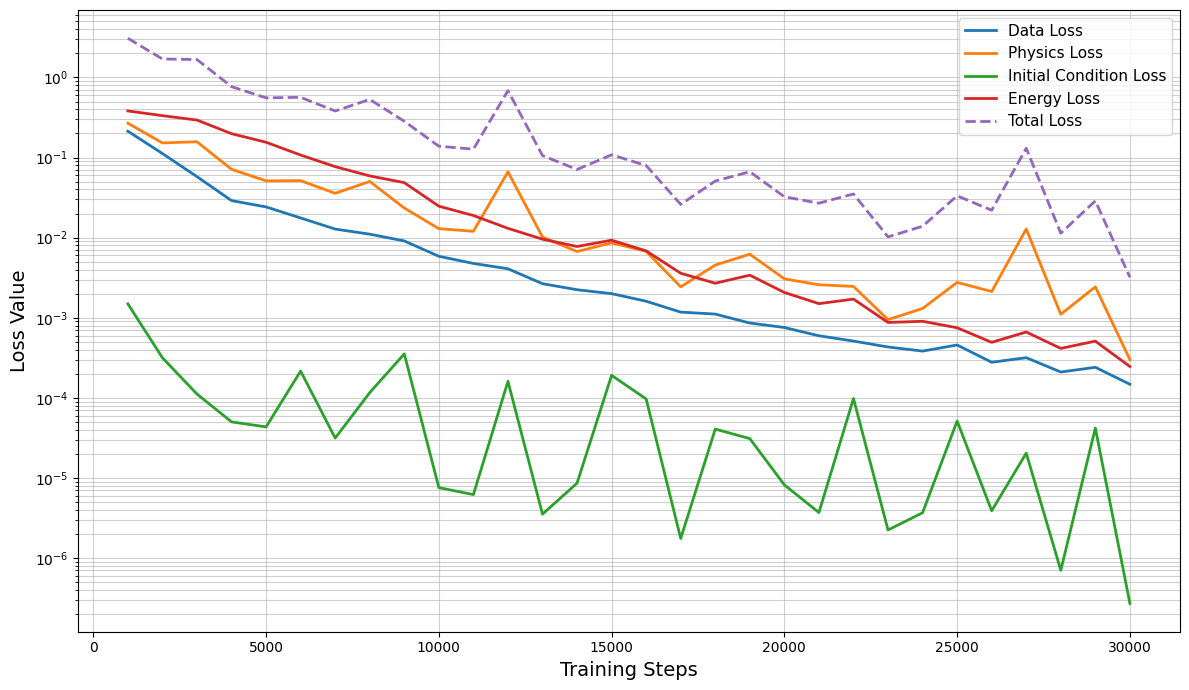

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# training steps
# Use the actual iteration numbers collected during training
training_steps_actual = np.array(iterations_history)

plt.figure(figsize=(12, 7))

# từng thành phần loss
plt.plot(
    training_steps_actual,
    loss_data_history,
    label='Data Loss',
    linewidth=2
)

plt.plot(
    training_steps_actual,
    loss_physics_history,
    label='Physics Loss',
    linewidth=2
)

plt.plot(
    training_steps_actual,
    loss_ic_history,
    label='Initial Condition Loss',
    linewidth=2
)

plt.plot(
    training_steps_actual,
    loss_energy_history,
    label='Energy Loss',
    linewidth=2
)

# loss tổng
plt.plot(
    training_steps_actual,
    total_loss_history,
    '--',
    label='Total Loss',
    linewidth=2
)

plt.xlabel('Training Steps', fontsize=14)
plt.ylabel('Loss Value', fontsize=14)

# log scale rất quan trọng
plt.yscale('log')

plt.legend(fontsize=11)
plt.grid(True, which="both", ls="-", alpha=0.6)

plt.tight_layout()
plt.show()

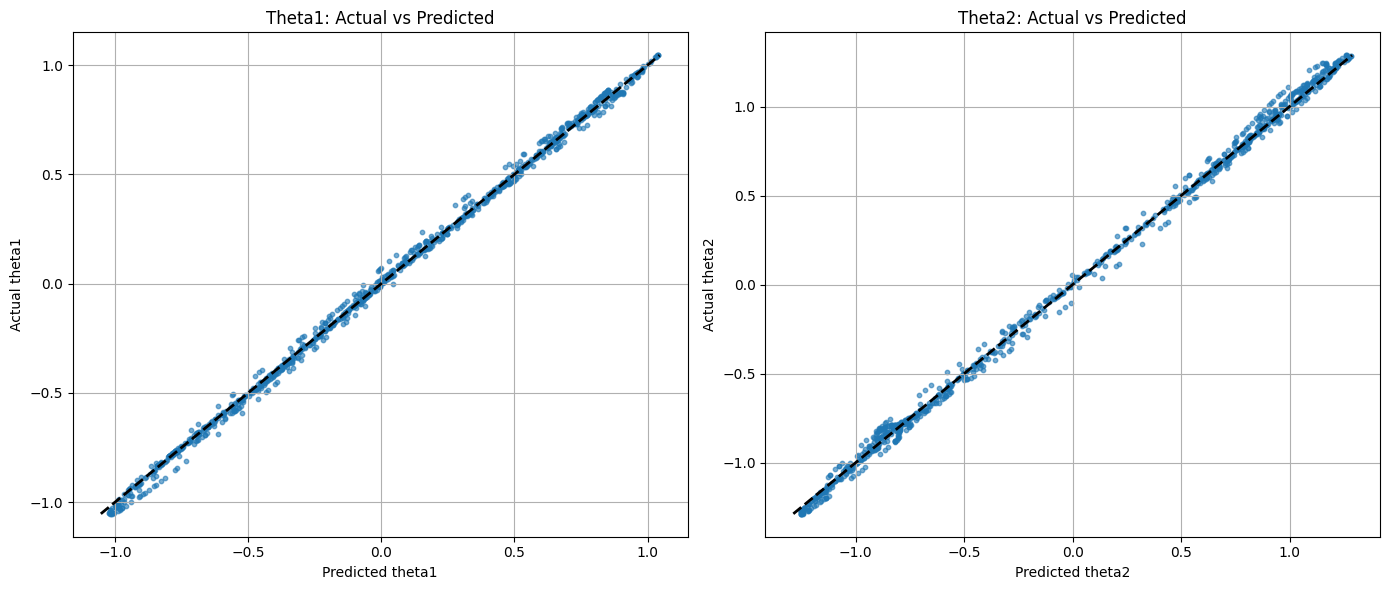

<Figure size 640x480 with 0 Axes>

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# =========================
# 1. Prediction từ model
# =========================
dp_model.eval()
with torch.no_grad():
    y_pred = dp_model(t_torch)

# Chuyển sang numpy
y_true = y_numerical.cpu().numpy()
y_pred = y_pred.cpu().numpy()

# Tách dữ liệu
theta1_true = y_true[:, 0]
theta2_true = y_true[:, 1]

theta1_pred = y_pred[:, 0]
theta2_pred = y_pred[:, 1]

# =========================
# 2. Lấy mẫu ngẫu nhiên
# =========================
n_points = 1000   # số điểm muốn hiển thị

idx = np.random.choice(len(theta1_true), n_points, replace=False)

theta1_true_sample = theta1_true[idx]
theta1_pred_sample = theta1_pred[idx]

theta2_true_sample = theta2_true[idx]
theta2_pred_sample = theta2_pred[idx]

# =========================
# 3. Vẽ scatter plot
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ===== theta1 =====
axes[0].scatter(
    theta1_pred_sample,
    theta1_true_sample,
    s=10,
    alpha=0.6
)

min_val = min(theta1_pred_sample.min(), theta1_true_sample.min())
max_val = max(theta1_pred_sample.max(), theta1_true_sample.max())

axes[0].plot(
    [min_val, max_val],
    [min_val, max_val],
    'k--',
    linewidth=2
)

axes[0].set_xlabel("Predicted theta1")
axes[0].set_ylabel("Actual theta1")
axes[0].set_title("Theta1: Actual vs Predicted")
axes[0].grid(True)

# ===== theta2 =====
axes[1].scatter(
    theta2_pred_sample,
    theta2_true_sample,
    s=10,
    alpha=0.6
)

min_val = min(theta2_pred_sample.min(), theta2_true_sample.min())
max_val = max(theta2_pred_sample.max(), theta2_true_sample.max())

axes[1].plot(
    [min_val, max_val],
    [min_val, max_val],
    'k--',
    linewidth=2
)

axes[1].set_xlabel("Predicted theta2")
axes[1].set_ylabel("Actual theta2")
axes[1].set_title("Theta2: Actual vs Predicted")
axes[1].grid(True)

plt.tight_layout()
plt.show()
plt.savefig("double_pendulum_plot.pdf", bbox_inches='tight')